In [5]:
df_big = pd.read_csv("diabetes3.csv")
print(df_big.shape)
df_big.head()

(253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


After SMOTE:
Diabetes_012
0.0    170908
1.0    170908
Name: count, dtype: int64

Logistic Regression Accuracy: 0.7301718700725324

Random Forest Accuracy: 0.8348509933774835

Confusion Matrix (Random Forest):
[[39825  2970]
 [ 5409  2532]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

         0.0       0.88      0.93      0.90     42795
         1.0       0.46      0.32      0.38      7941

    accuracy                           0.83     50736
   macro avg       0.67      0.62      0.64     50736
weighted avg       0.81      0.83      0.82     50736


Cross-validation Accuracy: 0.8430857773573004

Feature Importance:
                 Feature  Importance
3                    BMI    0.178378
13               GenHlth    0.153593
18                   Age    0.151743
20                Income    0.096589
0                 HighBP    0.074804
15              PhysHlth    0.073770
19             Education    0.052044
14              MentHlth    0

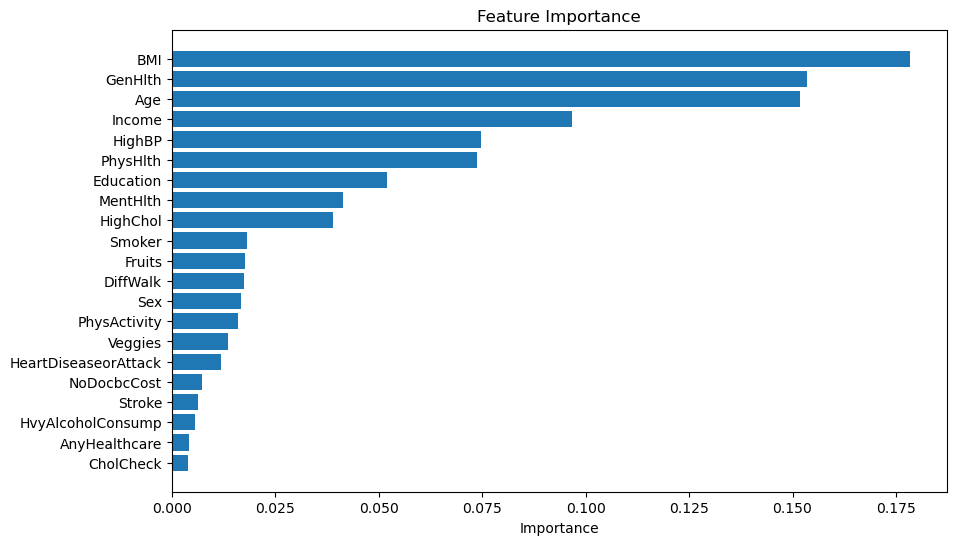

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("diabetes3.csv")

# ===============================
# 2. CONVERT TO BINARY (KEY STEP)
# ===============================
y = df["Diabetes_012"].replace({2: 1})
X = df.drop("Diabetes_012", axis=1)

# ===============================
# 3. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 4. SCALING
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

# ===============================
# 5. SMOTE (IMBALANCE FIX)
# ===============================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_res.value_counts())

# ===============================
# 6. LOGISTIC REGRESSION
# ===============================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# ===============================
# 7. RANDOM FOREST
# ===============================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# ===============================
# 8. EVALUATION
# ===============================
print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# ===============================
# 9. CROSS VALIDATION (OPTIONAL BONUS)
# ===============================
scores = cross_val_score(rf, X, y, cv=5)
print("\nCross-validation Accuracy:", scores.mean())

# ===============================
# 10. FEATURE IMPORTANCE (FINAL UPGRADE)
# ===============================
importances = rf.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

After SMOTE:
Diabetes_012
0.0    170908
1.0    170908
Name: count, dtype: int64

Logistic Regression Accuracy: 0.7301718700725324

Random Forest Accuracy: 0.8348509933774835

Confusion Matrix (Random Forest):
[[39825  2970]
 [ 5409  2532]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

         0.0       0.88      0.93      0.90     42795
         1.0       0.46      0.32      0.38      7941

    accuracy                           0.83     50736
   macro avg       0.67      0.62      0.64     50736
weighted avg       0.81      0.83      0.82     50736


Cross-validation Accuracy: 0.8430857773573004

Feature Importance:
                 Feature  Importance
3                    BMI    0.178378
13               GenHlth    0.153593
18                   Age    0.151743
20                Income    0.096589
0                 HighBP    0.074804
15              PhysHlth    0.073770
19             Education    0.052044
14              MentHlth    0

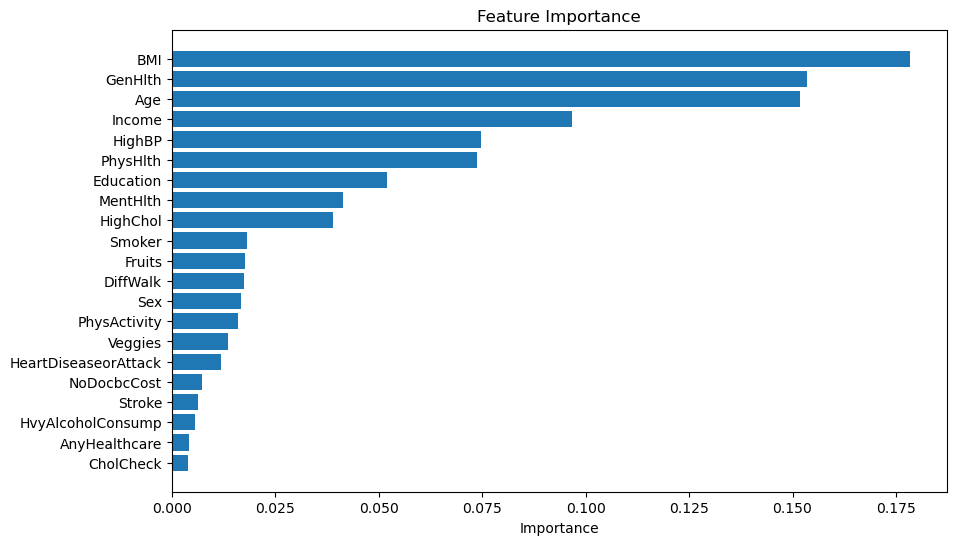

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("diabetes3.csv")

# ===============================
# 2. CONVERT TO BINARY (KEY STEP)
# ===============================
y = df["Diabetes_012"].replace({2: 1})
X = df.drop("Diabetes_012", axis=1)

# ===============================
# 3. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 4. SCALING
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

# ===============================
# 5. SMOTE (IMBALANCE FIX)
# ===============================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_res.value_counts())

# ===============================
# 6. LOGISTIC REGRESSION
# ===============================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# ===============================
# 7. RANDOM FOREST
# ===============================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# ===============================
# 8. EVALUATION
# ===============================
print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# ===============================
# 9. CROSS VALIDATION (OPTIONAL BONUS)
# ===============================
scores = cross_val_score(rf, X, y, cv=5)
print("\nCross-validation Accuracy:", scores.mean())

# ===============================
# 10. FEATURE IMPORTANCE (FINAL UPGRADE)
# ===============================
importances = rf.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [13]:
print(y.value_counts())

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


In [14]:
!pip install imbalanced-learn

In [19]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model saved successfully")

Model saved successfully
